In [137]:
import sys
import os
sys.path.append("../")
sys.path.append("../..")

In [138]:
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [139]:
from scale_rl.common.wandb_utils import *

In [140]:
from color import METHOD_COLORS, METHOD_BOUNDARY_COLORS, BORDER_GRAY

In [141]:
from scale_rl.envs.mujoco import MUJOCO_ALL, MUJOCO_RANDOM_SCORE, MUJOCO_TD3_SCORE
from scale_rl.envs.dmc import DMC_EASY_MEDIUM, DMC_HARD
from scale_rl.envs.humanoid_bench import HB_LOCOMOTION_NOHAND, HB_SUCCESS_SCORE, HB_RANDOM_SCORE
from scale_rl.envs.myosuite import MYOSUITE_TASKS

def replace_hypen_to_underbar(env_name_list):
    for idx in range(len(env_name_list)):
        env_name_list[idx] = env_name_list[idx].replace('-', '_')
    return env_name_list

In [142]:
td7_eval_df = pd.read_csv('../../results/baseline/td7.csv', index_col=0)
sac_simba_eval_df = pd.read_csv('/home/nas4_user/youngdolee/SimbaV2_dev_imp/results/baseline/simba_utd2.csv', index_col=0)
tdmpc2_eval_df = pd.read_csv('../../results/baseline/tdmpc2.csv', index_col=0)
dreamerv3_eval_df = pd.read_csv('../../results/baseline/dreamerv3.csv', index_col=0)
mrq_eval_df = pd.read_csv('../../results/baseline/mrq.csv', index_col=0)
simbav2_eval_df = pd.read_csv('../../results/hypersimba/hypersimba.csv', index_col=0)

In [143]:
simbav2_eval_df

,exp_name,env_name,seed,metric,env_step,value
0,hypersimba,h1-pole-v0,9000,avg_return,0.0,34.269159
1,hypersimba,h1-pole-v0,9000,avg_return,100000.0,303.279434
2,hypersimba,h1-pole-v0,9000,avg_return,200000.0,590.137001
3,hypersimba,h1-pole-v0,9000,avg_return,300000.0,657.775993
4,hypersimba,h1-pole-v0,9000,avg_return,400000.0,711.609390
...,...,...,...,...,...,...
13535,hypersimba,HalfCheetah-v4,0,avg_success,800000.0,0.000000
13536,hypersimba,HalfCheetah-v4,0,avg_success,850000.0,0.000000
13537,hypersimba,HalfCheetah-v4,0,avg_success,900000.0,0.000000
13538,hypersimba,HalfCheetah-v4,0,avg_success,950000.0,0.000000


In [144]:
td7_eval_df
td7_eval_df = td7_eval_df[td7_eval_df['env_step'] % 1e5 == 0]

In [145]:
sac_simba_eval_df['exp_name'] = 'Simba'
sac_simba_eval_df

,exp_name,env_name,seed,metric,env_step,value
0,Simba,Humanoid-v4,9000,avg_return,0.0,154.759782
1,Simba,Humanoid-v4,9000,avg_return,50000.0,929.994899
2,Simba,Humanoid-v4,9000,avg_return,100000.0,832.353516
3,Simba,Humanoid-v4,9000,avg_return,150000.0,4190.630537
4,Simba,Humanoid-v4,9000,avg_return,200000.0,6064.619006
...,...,...,...,...,...,...
26805,Simba,humanoid-stand,500,avg_success,800000.0,0.000000
26806,Simba,humanoid-stand,500,avg_success,850000.0,0.000000
26807,Simba,humanoid-stand,500,avg_success,900000.0,0.000000
26808,Simba,humanoid-stand,500,avg_success,950000.0,0.000000


In [146]:
tdmpc2_eval_df['exp_name'] = 'TD-MPC2'
tdmpc2_eval_df

,exp_name,env_name,seed,metric,env_step,value
82,TD-MPC2,acrobot-swingup,1,avg_return,0.0,7.6
83,TD-MPC2,acrobot-swingup,1,avg_return,100000.0,112.1
84,TD-MPC2,acrobot-swingup,1,avg_return,200000.0,219.4
85,TD-MPC2,acrobot-swingup,1,avg_return,300000.0,350.9
86,TD-MPC2,acrobot-swingup,1,avg_return,400000.0,283.2
...,...,...,...,...,...,...
11900,TD-MPC2,walker-walk-backwards,3,avg_return,3600000.0,980.3
11901,TD-MPC2,walker-walk-backwards,3,avg_return,3700000.0,978.1
11902,TD-MPC2,walker-walk-backwards,3,avg_return,3800000.0,984.8
11903,TD-MPC2,walker-walk-backwards,3,avg_return,3900000.0,986.1


In [147]:
dreamerv3_eval_df['exp_name'] = 'DreamerV3'
dreamerv3_eval_df = dreamerv3_eval_df[dreamerv3_eval_df['env_step'] % 1e5 == 0]
dreamerv3_eval_df

,exp_name,env_name,seed,metric,env_step,value
0,DreamerV3,acrobot_swingup,1,avg_return,0,13.120669
2,DreamerV3,acrobot_swingup,1,avg_return,100000,115.139457
4,DreamerV3,acrobot_swingup,1,avg_return,200000,142.569552
6,DreamerV3,acrobot_swingup,1,avg_return,300000,337.834131
8,DreamerV3,acrobot_swingup,1,avg_return,400000,304.989086
...,...,...,...,...,...,...
4044,DreamerV3,walker_walk,3,avg_return,100000,714.049536
4046,DreamerV3,walker_walk,3,avg_return,200000,859.590756
4048,DreamerV3,walker_walk,3,avg_return,300000,925.014982
4050,DreamerV3,walker_walk,3,avg_return,400000,792.896831


In [148]:
mrq_eval_df['exp_name'] = 'MR.Q'
mrq_eval_df = mrq_eval_df[mrq_eval_df['env_step'] % 1e5 == 0]
mrq_eval_df

,exp_name,env_name,seed,metric,env_step,value
0,MR.Q,Ant-v4,0,avg_return,0,-38.49426
1,MR.Q,Ant-v4,1,avg_return,0,-1321.10668
2,MR.Q,Ant-v4,2,avg_return,0,-554.50375
3,MR.Q,Ant-v4,3,avg_return,0,-392.88711
4,MR.Q,Ant-v4,4,avg_return,0,-641.16923
...,...,...,...,...,...,...
38325,MR.Q,walker-walk,5,avg_return,1000000,976.37956
38326,MR.Q,walker-walk,6,avg_return,1000000,977.33744
38327,MR.Q,walker-walk,7,avg_return,1000000,978.08139
38328,MR.Q,walker-walk,8,avg_return,1000000,980.16989


In [149]:
simbav2_eval_df['exp_name'] = 'SimbaV2'
simbav2_eval_df 

,exp_name,env_name,seed,metric,env_step,value
0,SimbaV2,h1-pole-v0,9000,avg_return,0.0,34.269159
1,SimbaV2,h1-pole-v0,9000,avg_return,100000.0,303.279434
2,SimbaV2,h1-pole-v0,9000,avg_return,200000.0,590.137001
3,SimbaV2,h1-pole-v0,9000,avg_return,300000.0,657.775993
4,SimbaV2,h1-pole-v0,9000,avg_return,400000.0,711.609390
...,...,...,...,...,...,...
13535,SimbaV2,HalfCheetah-v4,0,avg_success,800000.0,0.000000
13536,SimbaV2,HalfCheetah-v4,0,avg_success,850000.0,0.000000
13537,SimbaV2,HalfCheetah-v4,0,avg_success,900000.0,0.000000
13538,SimbaV2,HalfCheetah-v4,0,avg_success,950000.0,0.000000


In [150]:
BORDER_GRAY = "#D3D3D3"
simba_color = "#feb600"
simba_alpha_color = "#feb600"
# simba_color = METHOD_BOUNDARY_COLORS["Simba"] # sns.color_palette("YlOrBr",20)[8]
# simba_alpha_color = METHOD_COLORS["Simba"] # (*simba_color, 0.2)
tdmpc2_color = METHOD_BOUNDARY_COLORS["TD-MPC2"] # sns.color_palette("RdPu",20)[7]
tdmpc2_alpha_color = METHOD_BOUNDARY_COLORS["TD-MPC2"] # METHOD_COLORS["TD-MPC2"] # (*tdmpc2_color, 0.2)
td7_color = METHOD_BOUNDARY_COLORS["TD7"] # sns.color_palette("Blues",20)[8]
td7_alpha_color = METHOD_BOUNDARY_COLORS["TD7"] # METHOD_COLORS["TD7"] # (*td7_color, 0.2)
dreamerv3_color = METHOD_BOUNDARY_COLORS["DreamerV3"] # sns.color_palette("Purples",20)[9]
dreamerv3_alpha_color = METHOD_BOUNDARY_COLORS["DreamerV3"] #METHOD_COLORS["DreamerV3"] # (*dreamerv3_color, 0.2)
mrq_color = METHOD_BOUNDARY_COLORS["MR.Q"]
mrq_alpha_color = METHOD_COLORS["MR.Q"]
simbav2_color = METHOD_BOUNDARY_COLORS["SimbaV2"] # sns.color_palette("Purples",20)[9]
simbav2_alpha_color = METHOD_COLORS["SimbaV2"] # (*SimbaV2_color, 0.2)
colors = {
    'Simba': simba_color, 
    'TD7': td7_color, 
    'TD-MPC2': tdmpc2_color,
    'DreamerV3': dreamerv3_color, 
    'MR.Q': mrq_color,
    'SimbaV2': simbav2_color, 
}

In [151]:
simba_marker = 'o'# 'P'
tdmpc2_marker = 'o'# 's'
td7_marker = 'o' # '^'
dreamerv3_marker = 'o' # 'D'
mrq_marker = 'o'
simbav2_marker = 'o'
markers = {
    'SimbaV2': simbav2_marker,
    'Simba': simba_marker, 
    'TD7': td7_marker, 
    'TD-MPC2': tdmpc2_marker,
    'DreamerV3': dreamerv3_marker, 
    'MR.Q': mrq_marker,
}
markeverys = {
    'SimbaV2': {"Gym - MuJoCo": 4, "DMC Easy-Medium": 2, "DMC Hard": 2, "MyoSuite": 2, "HumanoidBench": 2},
    'MR.Q': {"Gym - MuJoCo": 2, "DMC Easy-Medium": 2, "DMC Hard": 2},
    'Simba': {"Gym - MuJoCo": 4, "DMC Easy-Medium": 2, "DMC Hard": 4, "MyoSuite": 4, "HumanoidBench": 4},
    'TD7': {"Gym - MuJoCo": 8, "DMC Easy-Medium": 8, "DMC Hard": 8, "MyoSuite": 2, "HumanoidBench": 2},
    'TD-MPC2': {"Gym - MuJoCo": 4, "DMC Easy-Medium": 4, "DMC Hard": 4, "MyoSuite": 4, "HumanoidBench": 4},
    'DreamerV3': {"Gym - MuJoCo": 8, "DMC Easy-Medium": 8, "DMC Hard": 8, "MyoSuite": 2, "HumanoidBench": 2},
}

In [152]:
import matplotlib.lines as mlines
simba_legend = mlines.Line2D([], [], color=simba_alpha_color, markeredgecolor=simba_color, marker=simba_marker, linestyle='None', markersize=13, label='Simba')
tdmpc2_legend = mlines.Line2D([], [], color=tdmpc2_alpha_color, markeredgecolor=tdmpc2_color, marker=tdmpc2_marker, linestyle='None', markersize=12, label='TD-MPC2')
dreamerv3_legend = mlines.Line2D([], [], color=dreamerv3_alpha_color, markeredgecolor=dreamerv3_color, marker=dreamerv3_marker, linestyle='None', markersize=10, label='DreamerV3')
td7_legend = mlines.Line2D([], [], color=td7_alpha_color, markeredgecolor=td7_color, marker=td7_marker, linestyle='None', markersize=13, label='TD7')

simbav2_legend = mlines.Line2D([], [], color=simbav2_alpha_color, markeredgecolor=simbav2_color, marker=simbav2_marker, linestyle='None', markersize=13, label='SimbaV2')

legend_handles = {
    'SimbaV2': simbav2_legend, 
    'Simba': simba_legend, 
    'TD7': td7_legend, 
    'TD-MPC2': tdmpc2_legend,
    'DreamerV3': dreamerv3_legend, 
}

# For plot
marker_sizes_all = {
    'SimbaV2': 125,
    'MR.Q': 125,
    'Simba': 125,
    'TD7': 125, # 100,
    'TD-MPC2': 125, # 100,
    'DreamerV3': 125, # 100,
}
marker_sizes = {
    'SimbaV2': 125, # 100,
    'MR.Q': 125,
    'Simba': 125, # 100,
    'TD7': 125, # 75,
    'TD-MPC2': 125, # 75,
    'DreamerV3': 125, # 50,
}

In [153]:
FONT_SIZE = 18

#### Collection

In [154]:
def replace_underbar_to_hypen(env_name_list):
    for idx in range(len(env_name_list)):
        env_name_list[idx] = env_name_list[idx].replace('_', '-')
    return env_name_list
def replace_underbar_to_hypen_dict(env_name_dict):
    _new_dict = {}
    for k, v in env_name_dict.items():
        _new_dict[k.replace('_', '-')] = v
    return _new_dict

In [155]:
MUJOCO_ALL = replace_underbar_to_hypen(MUJOCO_ALL)
DMC_EASY_MEDIUM = replace_underbar_to_hypen(DMC_EASY_MEDIUM)
DMC_HARD = replace_underbar_to_hypen(DMC_HARD)
HB_LOCOMOTION_NOHAND = replace_underbar_to_hypen(HB_LOCOMOTION_NOHAND)
MYOSUITE_TASKS = replace_underbar_to_hypen(MYOSUITE_TASKS)
DMC_ALL = [*DMC_EASY_MEDIUM, *DMC_HARD]

MUJOCO_RANDOM_SCORE = replace_underbar_to_hypen_dict(MUJOCO_RANDOM_SCORE)
MUJOCO_TD3_SCORE = replace_underbar_to_hypen_dict(MUJOCO_TD3_SCORE)
HB_SUCCESS_SCORE = replace_underbar_to_hypen_dict(HB_SUCCESS_SCORE)
HB_RANDOM_SCORE = replace_underbar_to_hypen_dict(HB_RANDOM_SCORE)

# Remove manipulation & with-hand tasks
HB_SUCCESS_SCORE = {k: v for k, v in HB_SUCCESS_SCORE.items() if k in HB_LOCOMOTION_NOHAND}
HB_RANDOM_SCORE = {k: v for k, v in HB_RANDOM_SCORE.items() if k in HB_LOCOMOTION_NOHAND}

In [156]:
eval_df = pd.concat([
    td7_eval_df,
    tdmpc2_eval_df,
    dreamerv3_eval_df,
    mrq_eval_df,
    sac_simba_eval_df, 
    simbav2_eval_df,
    ], ignore_index=True, sort=False)
eval_df['env_name'] = eval_df['env_name'].str.replace('_', '-')
eval_df

,exp_name,env_name,seed,metric,env_step,value
0,TD7,acrobot-swingup,1,avg_return,100000.0,69.333976
1,TD7,acrobot-swingup,1,avg_return,200000.0,15.802118
2,TD7,acrobot-swingup,1,avg_return,300000.0,24.520891
3,TD7,acrobot-swingup,1,avg_return,400000.0,39.813629
4,TD7,acrobot-swingup,1,avg_return,500000.0,47.569365
...,...,...,...,...,...,...
62366,SimbaV2,HalfCheetah-v4,0,avg_success,800000.0,0.000000
62367,SimbaV2,HalfCheetah-v4,0,avg_success,850000.0,0.000000
62368,SimbaV2,HalfCheetah-v4,0,avg_success,900000.0,0.000000
62369,SimbaV2,HalfCheetah-v4,0,avg_success,950000.0,0.000000


In [157]:
exp_names = eval_df['exp_name'].unique()
exp_names

array(['TD7', 'TD-MPC2', 'DreamerV3', 'MR.Q', 'Simba', 'SimbaV2'],
      dtype=object)

In [158]:
env_names = eval_df['env_name'].unique()
env_names

array(['acrobot-swingup', 'cartpole-balance', 'cartpole-balance-sparse',
       'cartpole-swingup', 'cartpole-swingup-sparse', 'cheetah-run',
       'dog-run', 'dog-stand', 'dog-trot', 'dog-walk', 'finger-spin',
       'finger-turn-easy', 'finger-turn-hard', 'fish-swim',
       'h1-balance-hard-v0', 'h1-balance-simple-v0', 'h1-crawl-v0',
       'h1-hurdle-v0', 'h1-maze-v0', 'h1-pole-v0', 'h1-reach-v0',
       'h1-run-v0', 'h1-sit-hard-v0', 'h1-sit-simple-v0', 'h1-slide-v0',
       'h1-stair-v0', 'h1-stand-v0', 'h1-walk-v0', 'hopper-hop',
       'hopper-stand', 'humanoid-run', 'humanoid-stand', 'humanoid-walk',
       'myo-key-turn', 'myo-key-turn-hard', 'myo-obj-hold',
       'myo-obj-hold-hard', 'myo-pen-twirl', 'myo-pen-twirl-hard',
       'myo-pose', 'myo-pose-hard', 'myo-reach', 'myo-reach-hard',
       'pendulum-swingup', 'quadruped-run', 'quadruped-walk',
       'reacher-easy', 'reacher-hard', 'walker-run', 'walker-stand',
       'walker-walk', 'cheetah-jump', 'cheetah-run-back',

### Visualization

In [159]:
MUJ_STEPS = 1000000 # 1M
DMC_STEPS = 1000000 # 1M
MYO_STEPS = 1000000 # 1M
HB_STEPS = 1000000 # 1M

In [160]:
def set_identical_grid(ax, x_num_ticks, y_num_ticks, tick_x_min, tick_x_max, tick_y_min, tick_y_max):
    # This function adds evenly spaced grid lines
    ax.xaxis.set_major_locator(plt.MaxNLocator(x_num_ticks, integer=True))
    ax.yaxis.set_major_locator(plt.MaxNLocator(y_num_ticks, integer=True))
    ax.xaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
    ax.yaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
    # Set ticks after limits are defined
    ax.set_xticks(np.linspace(tick_x_min, tick_x_max, x_num_ticks))
    ax.set_yticks(np.linspace(tick_y_min, tick_y_max, y_num_ticks))
    
def simple_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [161]:
def normalize_values(df, TASK_SUCCESS_SCORE):
    """
    Normalize the 'value' column in the DataFrame based on the TASK_SUCCESS_SCORE.

    Args:
    - df (pandas.DataFrame): Input DataFrame with columns 'env_name' and 'value'

    Returns:
    - pandas.DataFrame: DataFrame with normalized 'value' column
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_normalized = df.copy()

    # Define a function to normalize a single value
    def normalize_value(row):
        env_name = row["env_name"]
        value = row["value"]
        if env_name in TASK_SUCCESS_SCORE:
            return value / TASK_SUCCESS_SCORE[env_name] * 1000
        else:
            print(
                f"Warning: No normalization score found for environment '{env_name}'. Returning original value."
            )
            raise NotImplementedError

    # Apply the normalization function to each row
    df_normalized["value"] = df_normalized.apply(normalize_value, axis=1)

    return df_normalized

### ALL

In [162]:
def plot_multiple_environment_metrics(
    env_dfs,
    env_names,
    colors,
    metrics,
    x_lim_mins,
    x_lim_maxs,
    y_lim_mins,
    y_lim_maxs,
    y_labels,
    custom_titles,
    plot_width: int = 24,
    plot_height: int = 5,
    x_num_ticks: int = 5,
    y_num_ticks: int = 5,
    x_label: str = "Env steps (M)",
    line_width: float = 2.5,
):
    num_envs = len(env_dfs)
    # Set up the figure
    sns.set_style('darkgrid', {"axes.facecolor": "whitesmoke", "grid.color": "gray"})
    # sns.set_style('whitegrid')    
    
    fig, axs = plt.subplots(1, num_envs, figsize=(plot_width, plot_height), squeeze=False)
    fig.subplots_adjust(wspace=0.5)
    axs = axs.flatten()  # Flatten in case of a single subplot

    all_experiments = set()

    for i, (env_df, env_name) in enumerate(zip(env_dfs, env_names)):
        ax = axs[i]
        metric = metrics[i]
        x_lim_min = x_lim_mins[i]
        x_lim_max = x_lim_maxs[i]
        y_lim_min = y_lim_mins[i]
        y_lim_max = int(np.ceil(y_lim_maxs[i]))  # Round up to nearest integer

        env_df = env_df[env_df["metric"] == metric]
        experiments = env_df["exp_name"].unique()
        
        # custom
        experiments = ['SimbaV2', 'Simba', 'BRO', 'TD-MPC2', 'TD7', 'DreamerV3', 'SAC']
        
        all_experiments.update(experiments)

        for exp in experiments:
            exp_data = env_df[env_df["exp_name"] == exp]
            if len(exp_data) == 0:
                continue
            num_seeds = exp_data["seed"].nunique()
            
            # Check if env_step = 0 exists, if not, add it with value 0
            if 0 not in exp_data["env_step"].values:
                zero_row = pd.DataFrame({
                    "env_step": [0],
                    "value": [0],
                    "exp_name": [exp],
                    "metric": [metric]
                })
                exp_data = pd.concat([zero_row, exp_data]).reset_index(drop=True)
                
            # Group by env_step and calculate mean across all environments
            grouped_data = exp_data.groupby("env_step")["value"]
            
            env_steps = grouped_data.mean().index.values
            mean = grouped_data.mean().values
            std_error = grouped_data.sem().values  # Standard error of the mean

            # Multiply by 10 for MyoSuite
            if env_name == "MyoSuite":
                mean *= 100
                std_error *= 100
                y_lim_max = 100  # Set y_lim_max to 100 for percentage

            # Plot mean history with thicker lines
            from scipy.ndimage import convolve
            #mean = convolve(mean, [1/3,1/3,1/3])
            if exp == 'HyperSimba':
                zorder = 20
            else:
                zorder = 0
            ax.plot(env_steps, 
                    mean, 
                    label=exp, 
                    linewidth=line_width, 
                    color=colors[exp], 
                    marker=markers[exp], 
                    markevery=markeverys[exp][env_name],
                    zorder=zorder)
            
            # Draw markers
            # timestep_list = [0, 2e5, 4e5, 6e5, 8e5, 1e6]
            # markers_idx = list(range(0, len(mean), len(mean) // (x_num_ticks-1)))
            # timestep_list = [t for t in timestep_list if t <= max(env_steps)]
            # markers_idx = markers_idx[:len(timestep_list)]
            # markers_values = np.interp(timestep_list, env_steps, mean)
            # ax.scatter(timestep_list,
            #             markers_values,
            #             label=None,
            #             color=colors[exp], 
            #             edgecolor='white',
            #             marker=markers[exp], 
            #             s=marker_sizes_all[exp],
            #             zorder=zorder+5)

            # Fill between mean - std_error and mean + std_error
            ax.fill_between(
                env_steps,
                mean - 1.96*std_error,
                mean + 1.96*std_error,
                alpha=0.2,
                color=colors[exp],
            )

        # Set labels and limits
        ax.set_xlabel(x_label, fontsize=18)
        ax.set_autoscalex_on(False)
        ax.set_autoscaley_on(False)
        ax.set_xlim(x_lim_min, x_lim_max)
        ax.set_ylim(y_lim_min, y_lim_max)

        # Set x-ticks and format them
        x_ticks = np.linspace(x_lim_min, x_lim_max, x_num_ticks)
        ax.set_xticks(x_ticks)
        # Format x-tick labels
        x_tick_labels = []
        for tick in x_ticks:
            if tick == 0:
                x_tick_labels.append("0")
            else:
                x_tick_labels.append("{:.1f}".format(tick / 1e6))
        
        ax.set_xticklabels(x_tick_labels, fontsize=16)

        # Set y-ticks (only 3) and format them as integers
        y_ticks = np.linspace(y_lim_min, y_lim_max, y_num_ticks, dtype=int)
        ax.set_yticks(y_ticks)
        #ax.set_xscale('log')
        ax.set_yticklabels(["{:,d}".format(int(tick)) for tick in y_ticks], fontsize=16)

        # Add custom title with first line bold
        title = custom_titles[i]
        ax.set_title('')  # Clear any existing title
        ax.text(0.5, 1.03, title, transform=ax.transAxes, ha='center', va='bottom', fontsize=18)
        set_identical_grid(
            ax, 
            x_num_ticks=x_num_ticks, 
            y_num_ticks=y_num_ticks,
            tick_x_min=x_lim_min,
            tick_x_max=x_lim_max,
            tick_y_min=y_lim_min,
            tick_y_max=y_lim_max,
        )
        simple_axis(ax)
    
    # Add shared legend below the subplots
    _, labels = ax.get_legend_handles_labels()
    plt.subplots_adjust(bottom=0.15)

    # Add markers to the legend
    handles = [legend_handles[k] for k in labels]
    fig.legend(handles, labels, loc='lower center', ncol=len(all_experiments), bbox_to_anchor=(0.5, -0.12), fontsize='xx-large')
    
    # Adjust layout and display
    plt.savefig("all_learning_curve.png",bbox_inches='tight')

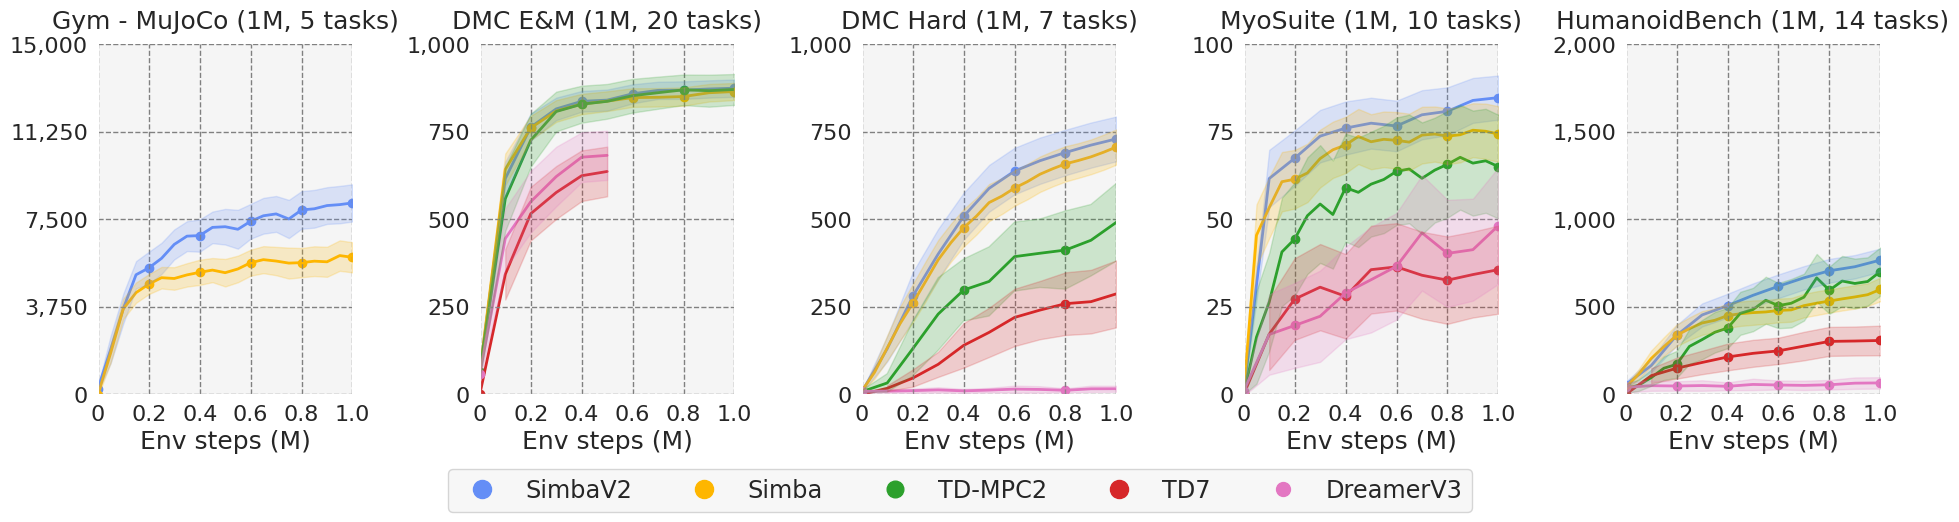

In [163]:
mujoco_eval_df = eval_df[eval_df['env_name'].isin(MUJOCO_ALL)]
dmc_easy_medium_eval_df = eval_df[eval_df['env_name'].isin(DMC_EASY_MEDIUM)]
dmc_hard_eval_df = eval_df[eval_df['env_name'].isin(DMC_HARD)]
myo_eval_df = eval_df[eval_df['env_name'].isin(MYOSUITE_TASKS)]
hb_eval_df = eval_df[eval_df['env_name'].isin(HB_LOCOMOTION_NOHAND)]
hb_eval_df = normalize_values(hb_eval_df, HB_SUCCESS_SCORE)

plot_multiple_environment_metrics(
    env_dfs=[mujoco_eval_df, dmc_easy_medium_eval_df, dmc_hard_eval_df, myo_eval_df, hb_eval_df],
    env_names=["Gym - MuJoCo", "DMC Easy-Medium", "DMC Hard", "MyoSuite", "HumanoidBench"],
    metrics=["avg_return", "avg_return", "avg_return", "avg_success", "avg_return"],
    colors=colors,
    x_lim_mins=[0, 0, 0, 0, 0],
    x_lim_maxs=[1.0e6, 1.0e6, 1.0e6, 1.0e6, 1.0e6],
    y_lim_mins=[0, 0, 0, 0, 0],
    y_lim_maxs=[15000, 1000, 1000, 100, 2000],
    y_labels=["Average Return", "Success Rate"],
    custom_titles=[
        "Gym - MuJoCo (1M, 5 tasks)",
        "DMC E&M (1M, 20 tasks)",
        "DMC Hard (1M, 7 tasks)",
        "MyoSuite (1M, 10 tasks)",
        "HumanoidBench (1M, 14 tasks)",
    ],
    x_num_ticks=6,
    line_width=2.0,
    plot_width= 23,
    plot_height= 4.8,
)

### Per environments

In [164]:
TITLE_FONTSIZE = 14
X_FONTSIZE = 14
Y_FONTSIZE = 14

In [165]:
def plot_environment_metrics_per_env(
    env_dfs,
    env_names,
    env_dicts,
    colors,
    metrics,
    x_lim_mins,
    x_lim_maxs,
    y_lim_mins,
    y_lim_maxs,
    y_labels,
    plot_widths: list,
    plot_heights: list,
    plot_hspaces: list,
    plot_wspaces: list,
    legend_bbox_to_anchors: list,
    num_plots_per_row=4,
    x_num_ticks: int = 6,
    y_num_ticks: int = 5,
    x_label: str = "Env steps (M)",
    line_width: float = 2.5
):
    for i, env_dict in enumerate(env_dicts):
        # indexing
        metric = metrics[i]
        x_lim_min, x_lim_max = x_lim_mins[i], x_lim_maxs[i]
        if i > 0 and i < len(env_dicts) - 1:
            y_lim_min, y_lim_max = y_lim_mins[i], int(np.ceil(y_lim_maxs[i]))  # Round up to nearest integer
        elif i == len(env_dicts) - 1:
            hb_y_info = y_lim_maxs[-1]
        else:
            mujoco_y_info = y_lim_mins[0]
        y_label = y_labels[i]
        plot_width, plot_height = plot_widths[i], plot_heights[i]
        wspace, hspace = plot_wspaces[i], plot_hspaces[i]
        bbox_to_anchor = legend_bbox_to_anchors[i]
        env_df, env_name = env_dfs[i], env_names[i]
            
        num_plots = len(env_dict)
        ncols = min(num_plots_per_row, num_plots)
        nrows = (num_plots + ncols - 1) // ncols  # Calculate number of rows needed
        num_removes = ncols * nrows - num_plots 
        
        # Set up the figure
        # sns.set_style('darkgrid', {"axes.facecolor": "white", "grid.color": BORDER_GRAY})
        sns.set_style('whitegrid')    
        
        fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(plot_width, plot_height), squeeze=False)
        fig.subplots_adjust(hspace=hspace, wspace=wspace)
        axs = axs.flatten()  # Flatten in case of a single subplot
        
        for _elim_idx in range(1, num_removes+1):
            axs.flat[-1 * _elim_idx].set_visible(False) # # Remove empty subplots

        all_experiments = set()

        for j, env in enumerate(env_dict):
            ax = axs[j] # plot for env_name
            
            env_data = env_df[env_df["env_name"] == env]
            env_data = env_data[env_data["metric"] == metric]
            experiments = env_data["exp_name"].unique()
            
            # custom
            if env_name in ["Gym - MuJoCo", "DMC Easy-Medium", "DMC Hard"]:
                experiments = ['MR.Q', 'Simba', 'SimbaV2'] #, 'TD-MPC2', 'TD7', 'DreamerV3']
            else:
                experiments = ["DreamerV3", "TD7", "TD-MPC2", "Simba", "SimbaV2"]
            
            all_experiments.update(experiments)

            for exp in experiments:
                exp_data = env_data[env_data["exp_name"] == exp]
                exp_data = exp_data[exp_data["env_step"] <= x_lim_max]
                if len(exp_data) == 0:
                    continue
                
                num_seeds = exp_data["seed"].nunique()
                
                # Check if env_step = 0 exists, if not, add it with value 0
                if 0 not in exp_data["env_step"].values:
                    zero_row = pd.DataFrame({
                        "env_step": [0],
                        "value": [0],
                        "exp_name": [exp],
                        "metric": [metric]
                    })
                    exp_data = pd.concat([zero_row, exp_data]).reset_index(drop=True)
                    
                # Group by env_step and calculate mean across all environments
                grouped_data = exp_data.groupby(["env_step"])["value"]
                env_steps = grouped_data.mean().index.values
                mean = grouped_data.mean().values
                std_error = grouped_data.sem().values  # Standard error of the mean

                # Multiply by 10 for MyoSuite
                if env_name == "MyoSuite":
                    mean *= 100
                    std_error *= 100
                    y_lim_max = 100  # Set y_lim_max to 100 for percentage

                # Plot mean history with thicker lines
                from scipy.ndimage import convolve
                # mean = convolve(mean, [1/3,1/3,1/3])
                if exp == 'SimbaV2':
                    zorder = 30
                elif exp == 'Simba':
                    zorder = 20
                elif exp == 'TD-MPC2' or exp == 'MR.Q':
                    zorder = 10
                elif exp == 'DreamerV3':
                    zorder = 0
                else:
                    zorder = -10
                ax.plot(env_steps, 
                        mean, 
                        label=exp, 
                        linewidth=line_width, 
                        color=colors[exp], 
                        marker=markers[exp], 
                        markevery=markeverys[exp][env_name],
                        zorder=zorder)
                
                
                # Draw markers
                # timestep_list = [0, 2e5, 4e5, 6e5, 8e5, 1e6]
                # markers_idx = list(range(0, len(mean), len(mean) // (x_num_ticks-1)))
                # timestep_list = [t for t in timestep_list if t <= max(env_steps)]
                # markers_idx = markers_idx[:len(timestep_list)]
                # markers_values = np.interp(timestep_list, env_steps, mean)
                # ax.scatter(timestep_list,
                #            markers_values,
                #            label=None,
                #            color=colors[exp], 
                #            edgecolor='white',
                #            marker=markers[exp], 
                #            s=marker_sizes[exp],
                #            zorder=zorder+5)

                # Fill between mean - std_error and mean + std_error
                ax.fill_between(
                    env_steps,
                    mean - 1.96*std_error,
                    mean + 1.96*std_error,
                    alpha=0.2,
                    color=colors[exp],
                )
            
            # Set labels and limits
            ax.set_xlabel(x_label, fontsize=X_FONTSIZE)
            if j % num_plots_per_row == 0: 
                ax.set_ylabel(y_label, fontsize=Y_FONTSIZE) # set ylabels for only leftmost subplots
            
            x_len = x_lim_max - x_lim_min
            ax.set_xlim(x_lim_min - 0.1*x_len, x_lim_max + 0.1*x_len)
            if env_name == "Gym - MuJoCo":
                y_lim_min, y_lim_max = mujoco_y_info[env]["y_lim_min"], mujoco_y_info[env]["y_lim_max"]
                y_len = y_lim_max - y_lim_min
                ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)
            elif env_name == "HumanoidBench":
                y_lim_max = hb_y_info[env]['y_lim_max']
                y_lim_min = 0
                y_len = y_lim_max
                ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)
                
                if HB_SUCCESS_SCORE[env] <= y_lim_max:
                    ax.axhline(y=HB_SUCCESS_SCORE[env], color='black', linestyle='--') 
                    
                    ax.text(0.025, HB_SUCCESS_SCORE[env] - hb_y_info[env].get("y_success_offset", 100), "Success", transform=ax.get_yaxis_transform(), color='black') #, transform=ax.get_yaxis_transform())
            else:
                y_len = y_lim_max - y_lim_min
                ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)

            # Set x-ticks and format them
            x_ticks = np.linspace(x_lim_min, x_lim_max, x_num_ticks)
            ax.set_xticks(x_ticks)
            # Format x-tick labels
            x_tick_labels = []
            for tick in x_ticks:
                if tick == 0:
                    x_tick_labels.append("0")
                else:
                    x_tick_labels.append("{:.1f}".format(tick / 1e6))
            
            ax.set_xticklabels(x_tick_labels, fontsize=12)

            if env_name == "Gym - MuJoCo":
                # Set y-ticks (only 3) and format them as integers
                y_num_ticks = mujoco_y_info[env]["y_num_ticks"]
                y_lim_min, y_lim_max = mujoco_y_info[env]["y_lim_min"], mujoco_y_info[env]["y_lim_max"]
                y_ticks = np.linspace(y_lim_min, y_lim_max, y_num_ticks, dtype=int)
                ax.set_yticks(y_ticks)
                #ax.set_xscale('log')
                ax.set_yticklabels(["{:,d}K".format(int(tick / 1000)) for tick in y_ticks], fontsize=12)
            elif env_name == "HumanoidBench":
                # Set y-ticks (only 3) and format them as integers
                y_num_ticks = hb_y_info[env].get("y_num_ticks", 5)
                y_lim_min, y_lim_max = 0, hb_y_info[env]["y_lim_max"]
                y_ticks = np.linspace(y_lim_min, y_lim_max, y_num_ticks, dtype=int)
                ax.set_yticks(y_ticks)
            else:
                # Set y-ticks (only 3) and format them as integers
                y_num_ticks = 5
                y_ticks = np.linspace(y_lim_min, y_lim_max, y_num_ticks, dtype=int)
                ax.set_yticks(y_ticks)
                #ax.set_xscale('log')
                ax.set_yticklabels(["{:,d}".format(int(tick)) for tick in y_ticks], fontsize=12)
            
            set_identical_grid(
                ax, 
                x_num_ticks=x_num_ticks, 
                y_num_ticks=y_num_ticks,
                tick_x_min=x_lim_min,
                tick_x_max=x_lim_max,
                tick_y_min=y_lim_min,
                tick_y_max=y_lim_max,
            )
            simple_axis(ax)
            
            # Add custom title with first line bold
            title = env
            ax.set_title('')  # Clear any existing title
            ax.text(0.5, 1.08, title, transform=ax.transAxes, ha='center', va='bottom', fontsize=TITLE_FONTSIZE)
            
            ax.use_sticky_edges = False
            ax.set_xmargin(5.25)
            ax.set_ymargin(2.5)        

        # Add shared legend below the subplots
        handles, labels = ax.get_legend_handles_labels()
        plt.subplots_adjust(bottom=0.15)

        # Add markers to the legend
        # handles = [legend_handles[k] for k in labels]
        leg = fig.legend(handles, labels, loc='lower center', ncol=len(all_experiments), bbox_to_anchor=bbox_to_anchor, fontsize='x-large',) # handletextpad=0.1,)
        leg.get_frame().set_linewidth(0.0)

        # Adjust layout and display
        save = {
            "Gym - MuJoCo": "gym",
            "DMC Easy-Medium": "dmc_em",
            "DMC Hard": "dmc_hard",
            "MyoSuite": "myo",
            "HumanoidBench": "hb",
        }
        plt.savefig(f"appendix_{save[env_name]}_learning_curve.png",bbox_inches='tight')
        plt.savefig(f"appendix_{save[env_name]}_learning_curve.pdf",bbox_inches='tight')

In [166]:
mujoco_y_info = {
    "Ant-v4": {
        "y_lim_min": -2000,
        "y_lim_max": 10000,
        "y_num_ticks": 4,
    },
    "HalfCheetah-v4": {
        "y_lim_min": -2000,
        "y_lim_max": 18000, 
        "y_num_ticks": 5,
    },
    "Hopper-v4": {
        "y_lim_min": -1000,
        "y_lim_max": 4000, 
        "y_num_ticks": 5,
    },
    "Humanoid-v4": {
        "y_lim_min": -2000,
        "y_lim_max": 12000, 
        "y_num_ticks": 5,
    },
    "Walker2d-v4": {
        "y_lim_min": -1000,
        "y_lim_max": 8000, 
        "y_num_ticks": 5,
    }
}

In [167]:
hb_y_lim_max_info = {
    "h1-walk-v0": {
        "y_lim_max": 1000,
    },
    "h1-stand-v0": {
        "y_lim_max": 1000,
    },
    "h1-run-v0": {
        "y_lim_max": 1000,
    },
    "h1-reach-v0": {
        "y_lim_max": 15000,
        "y_num_ticks": 7,
        "y_success_offset": 1500,
    },
    "h1-hurdle-v0": {
        "y_lim_max": 1000,
    },
    "h1-crawl-v0": {
        "y_lim_max": 1000,
    },
    "h1-maze-v0": {
        "y_lim_max": 1500,
        "y_num_ticks": 7,
        "y_success_offset": 150,
    },
    "h1-sit-simple-v0": {
        "y_lim_max": 1000,
    },
    "h1-sit-hard-v0": {
        "y_lim_max": 1000,
    },
    "h1-balance-simple-v0": {
        "y_lim_max": 1000,
    },
    "h1-balance-hard-v0": {
        "y_lim_max": 1000,
    },
    "h1-stair-v0": {
        "y_lim_max": 1000,
    },
    "h1-slide-v0": {
        "y_lim_max": 1000,
    },
    "h1-pole-v0": {
        "y_lim_max": 1000,
    },
}

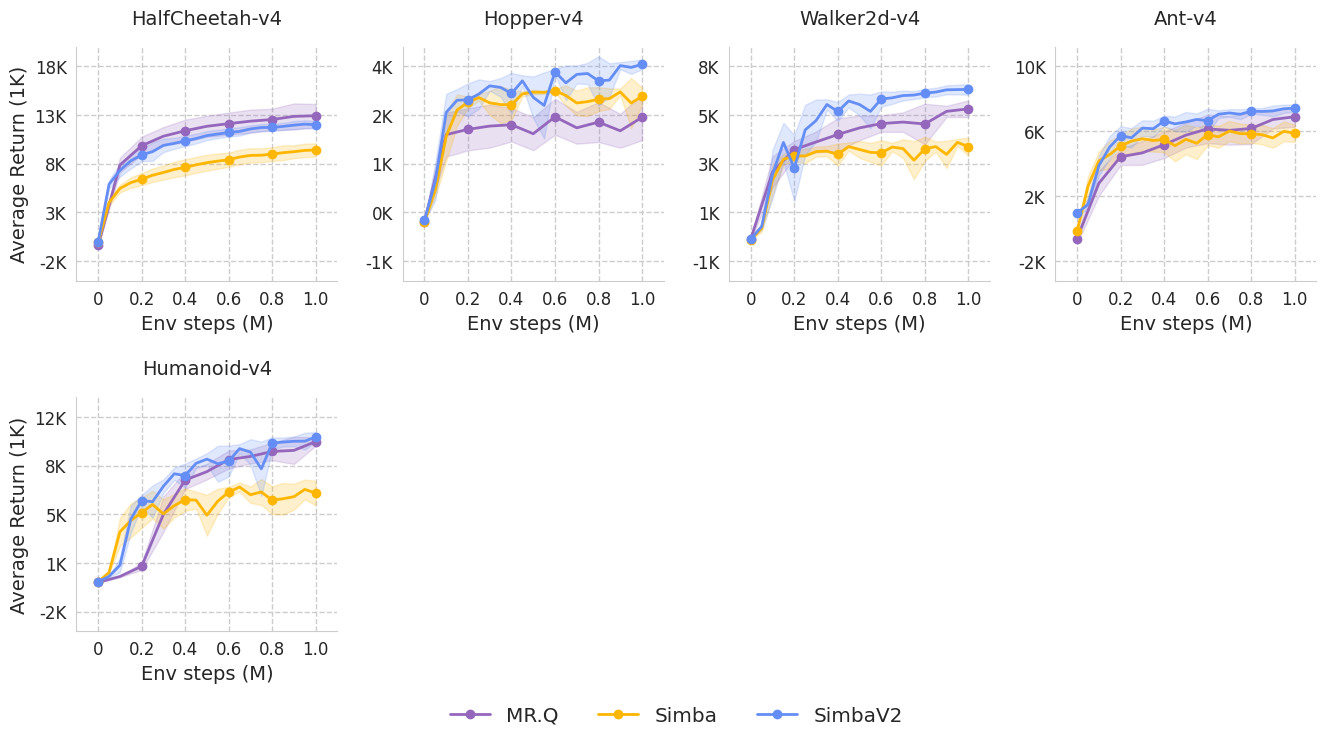

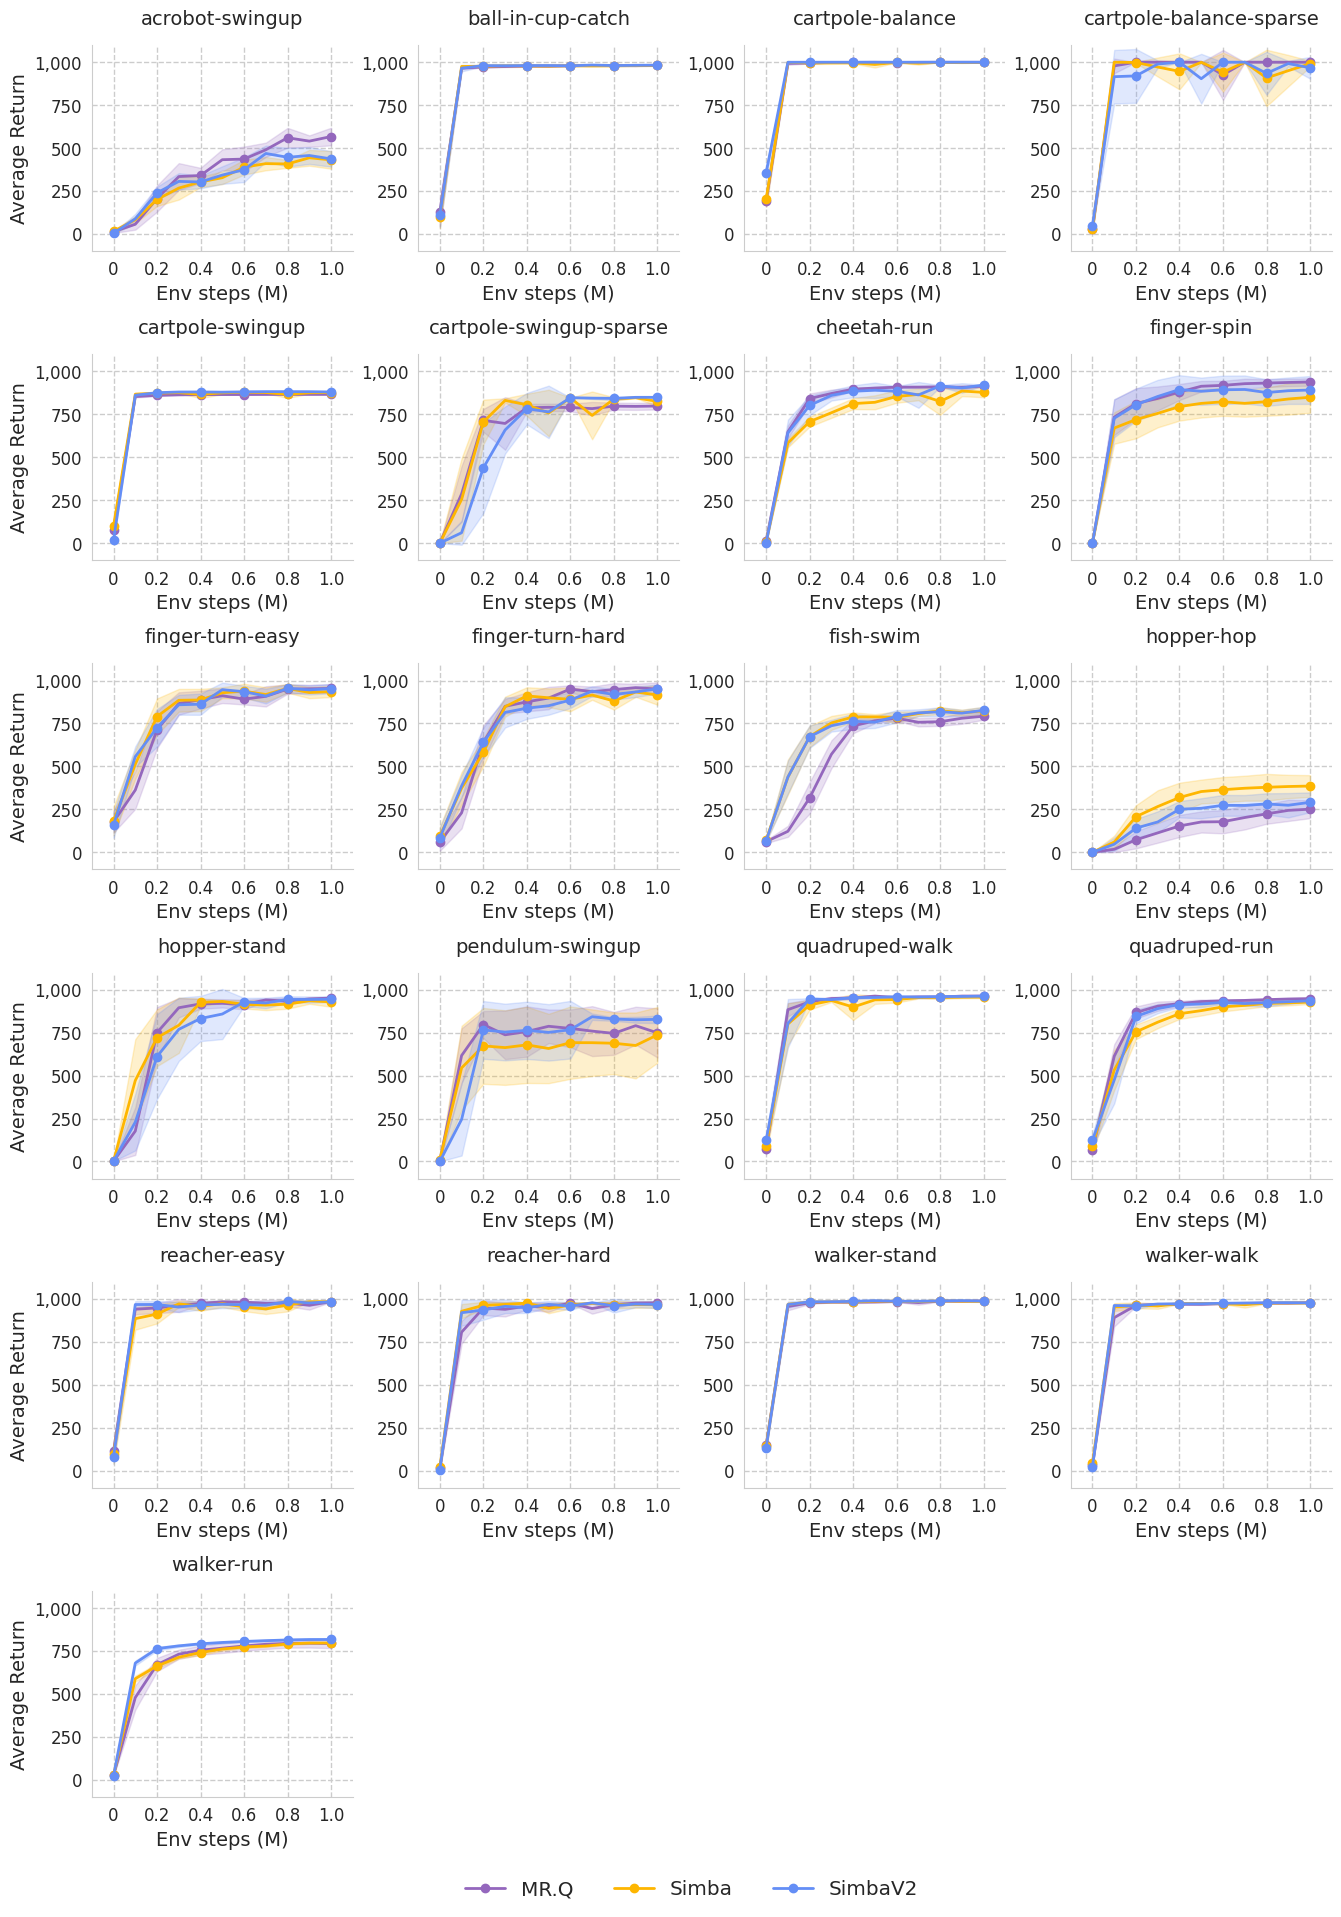

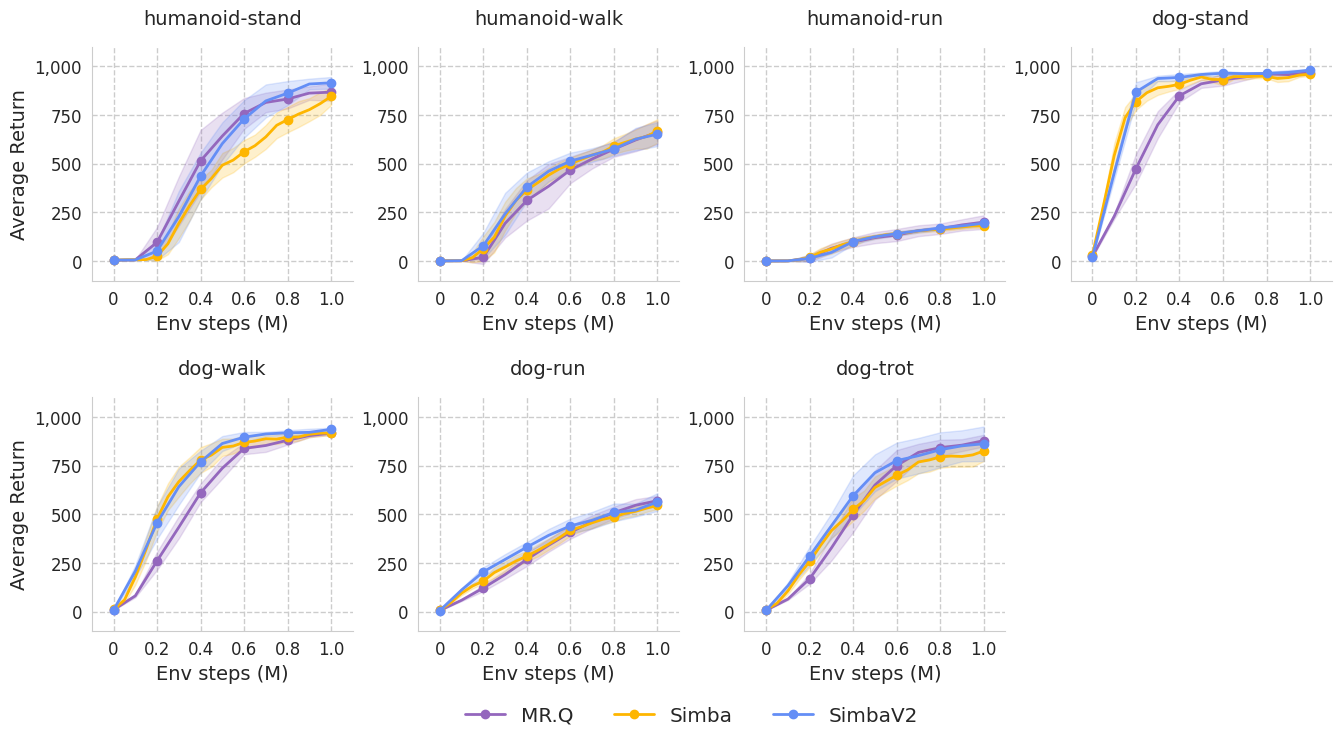

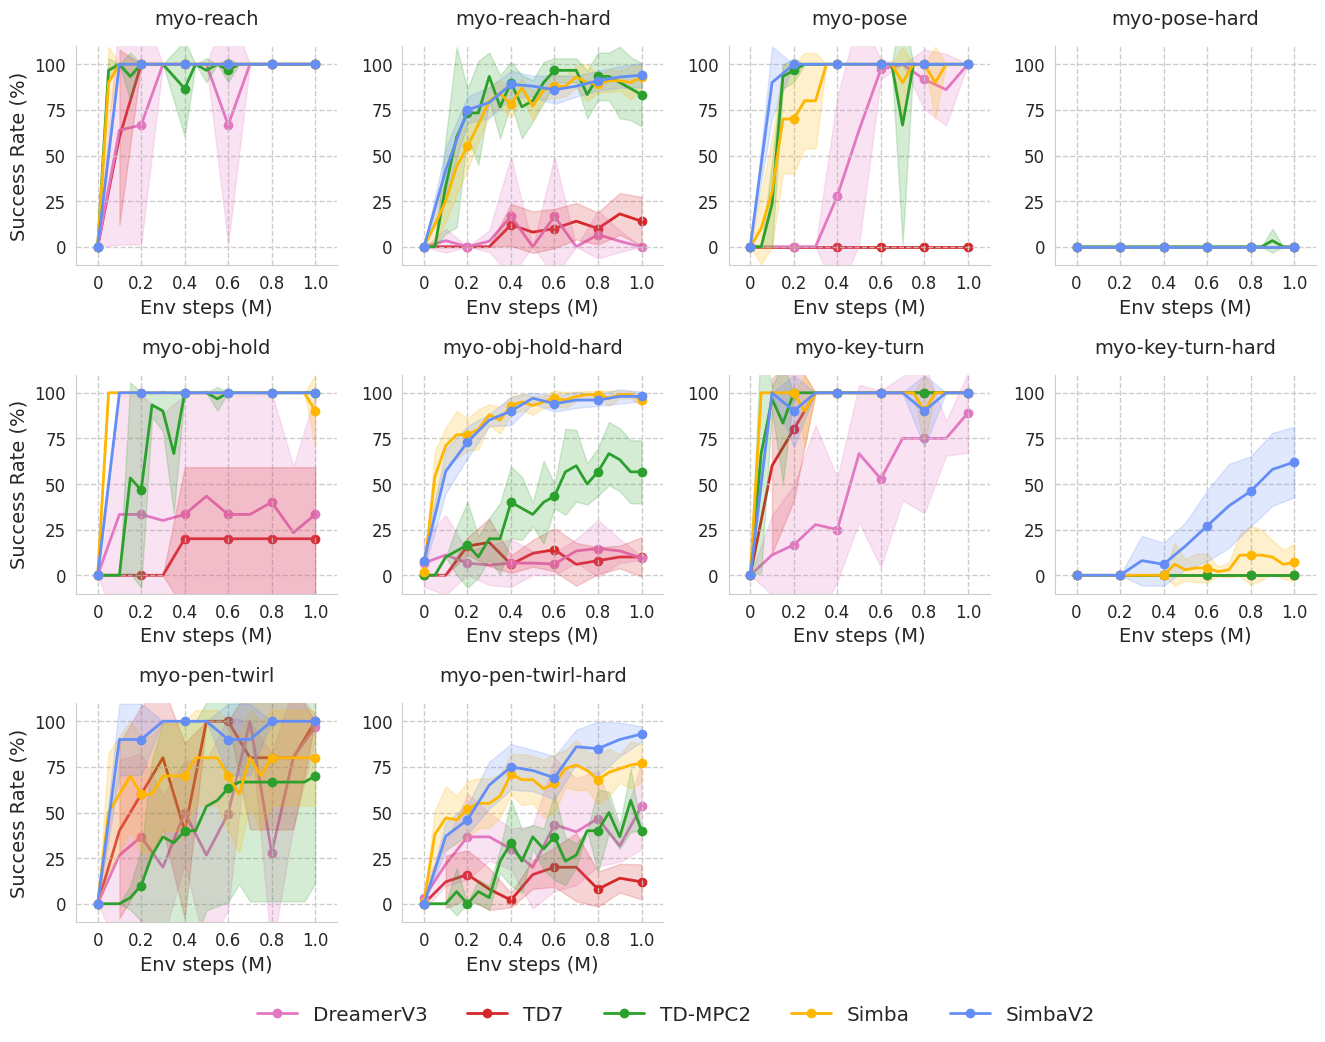

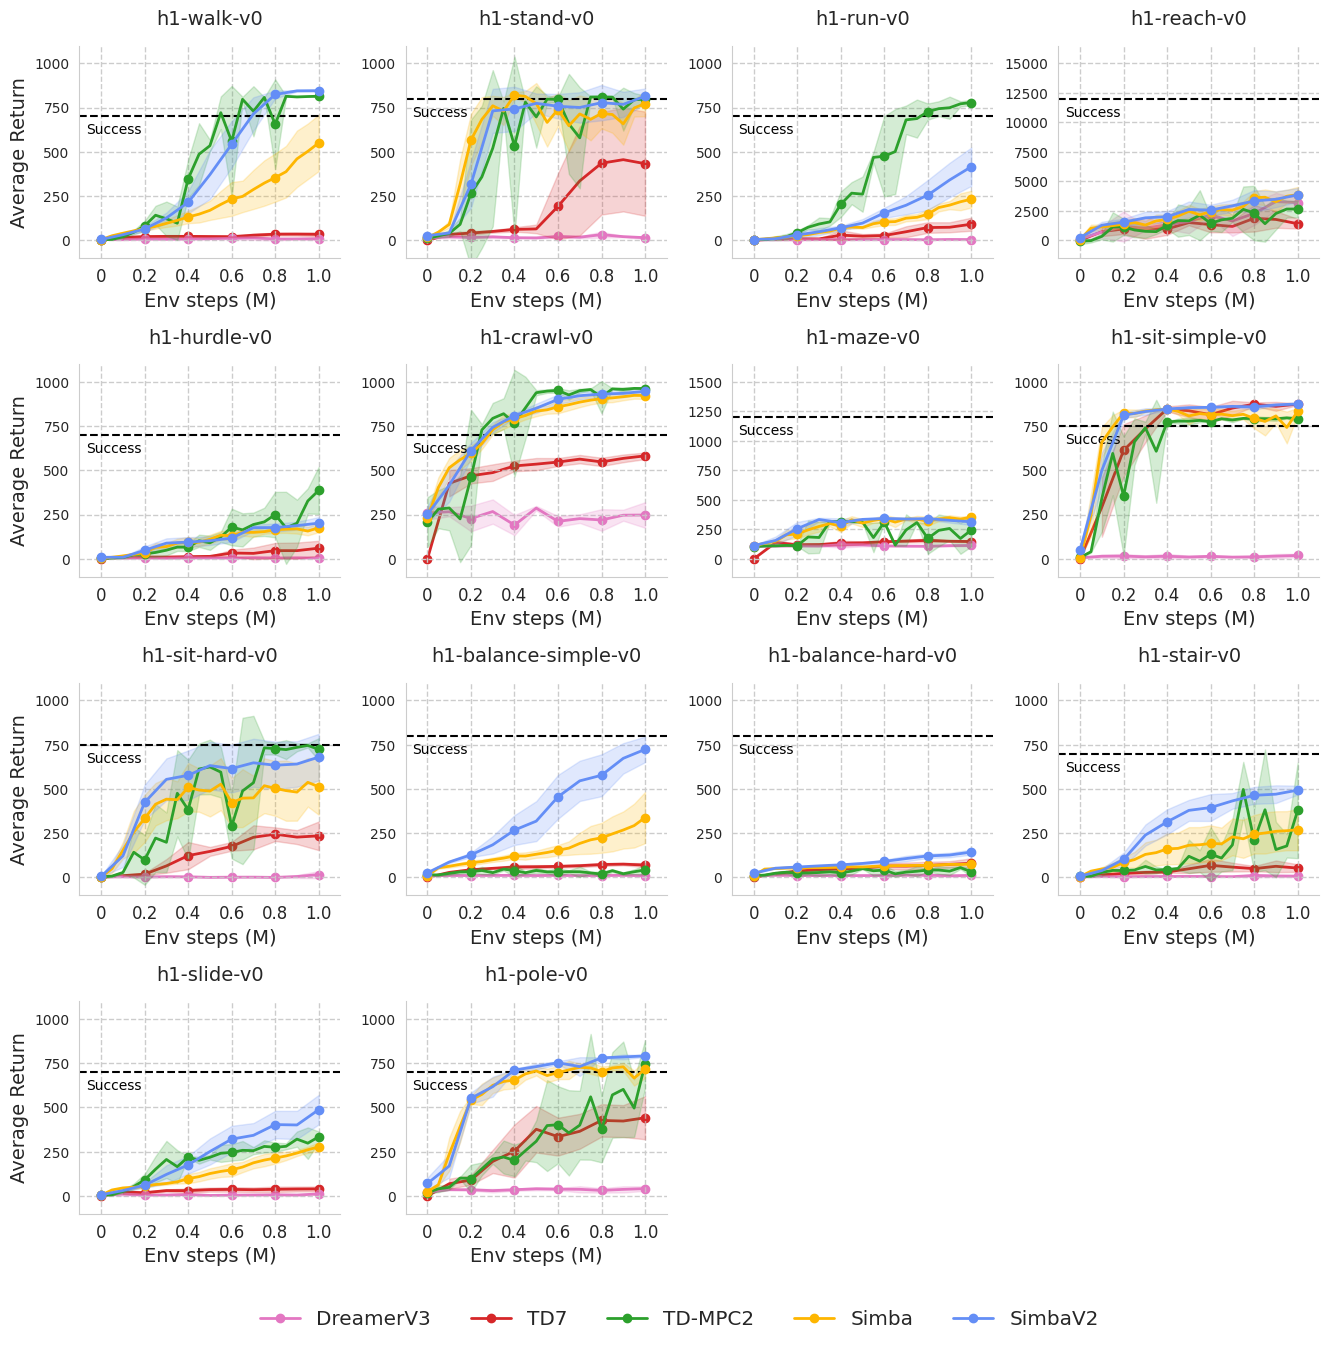

In [168]:
mujoco_eval_df = eval_df[eval_df['env_name'].isin(MUJOCO_ALL)]
dmc_easy_medium_eval_df = eval_df[eval_df['env_name'].isin(DMC_EASY_MEDIUM)]
dmc_hard_eval_df = eval_df[eval_df['env_name'].isin(DMC_HARD)]
myo_eval_df = eval_df[eval_df['env_name'].isin(MYOSUITE_TASKS)]
hb_eval_df = eval_df[eval_df['env_name'].isin(HB_LOCOMOTION_NOHAND)]

plot_environment_metrics_per_env(
    env_dfs=[mujoco_eval_df, dmc_easy_medium_eval_df, dmc_hard_eval_df, myo_eval_df, hb_eval_df],
    env_names=["Gym - MuJoCo", "DMC Easy-Medium", "DMC Hard", "MyoSuite", "HumanoidBench"],
    env_dicts=[MUJOCO_ALL, DMC_EASY_MEDIUM, DMC_HARD, MYOSUITE_TASKS, HB_LOCOMOTION_NOHAND],
    metrics=["avg_return", "avg_return", "avg_return", "avg_success", "avg_return"],
    colors=colors,
    x_lim_mins=[0, 0, 0, 0, 0],
    x_lim_maxs=[1.0e6, 1.0e6, 1.0e6, 1.0e6, 1.0e6],
    y_lim_mins=[mujoco_y_info, 0, 0, 0, 0],
    y_lim_maxs=[mujoco_y_info, 1000, 1000, 100, hb_y_lim_max_info],
    y_labels=["Average Return (1K)", "Average Return", "Average Return", "Success Rate (%)", "Average Return"],
    line_width=2.0,
    num_plots_per_row=4,
    plot_widths=[16.0, 16.0, 16.0, 16.0, 16.0],
    plot_heights=[8.0, 24.0, 8.0, 12.0, 16.0],
    plot_hspaces=[0.5, 0.5, 0.5, 0.5, 0.5],
    plot_wspaces=[0.25, 0.25, 0.25, 0.25, 0.25],
    legend_bbox_to_anchors=[(0.5, 0.01), (0.5, 0.10), (0.5, 0.01), (0.5, 0.05), (0.5, 0.06666666)]
)